# Chapter 8: From dice to A/B tests

Each loop in `chapter.log` has a runnable cell here. Tune `n`, the conversion rates, the sigma, and re-run.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from expkit.sim.abtest import two_arm_binary, two_arm_continuous, stratified_binary
from expkit.inference.normal import two_proportion_z, two_sample_t
from expkit.inference.bootstrap import bootstrap_diff_ci
from expkit.plot.style import apply_style, PALETTE
apply_style()

## Loop A and B: same effect, different N

1pp lift on a 5% baseline. At N=1000 per arm, neither lens has enough power. At N=10000, both lenses see it clearly.

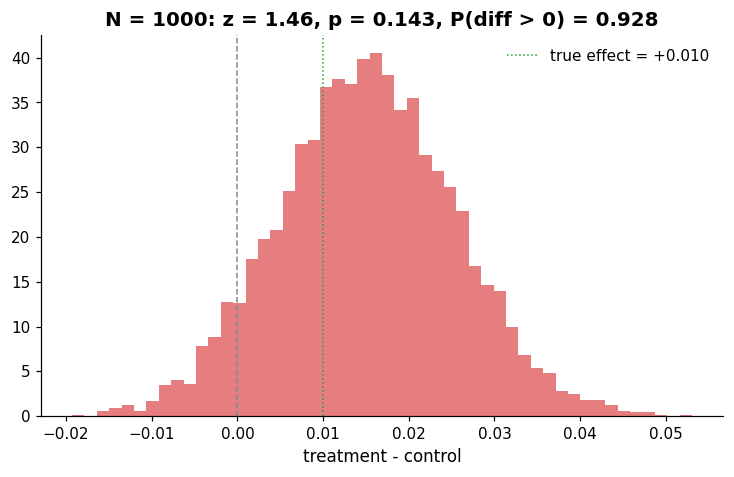

In [2]:
def show_two_arm(n, p_c=0.05, p_t=0.06, seed=0):
    exp = two_arm_binary(n, p_c, p_t, seed=seed)
    z = two_proportion_z(int(exp.treatment.sum()), n, int(exp.control.sum()), n)
    rng = np.random.default_rng(0)
    a_c, b_c = 1 + int(exp.control.sum()), 1 + (n - int(exp.control.sum()))
    a_t, b_t = 1 + int(exp.treatment.sum()), 1 + (n - int(exp.treatment.sum()))
    diffs = rng.beta(a_t, b_t, 5000) - rng.beta(a_c, b_c, 5000)
    fig, ax = plt.subplots()
    ax.hist(diffs, bins=50, density=True, color=PALETTE['bayesian'], alpha=0.6)
    ax.axvline(0, color=PALETTE['muted'], linestyle='--', linewidth=1)
    ax.axvline(p_t - p_c, color=PALETTE['highlight'], linestyle=':', linewidth=1, label=f'true effect = {p_t-p_c:+.3f}')
    ax.set_xlabel('treatment - control'); ax.set_title(f'N = {n}: z = {z.statistic:.2f}, p = {z.p_value:.3g}, P(diff > 0) = {(diffs > 0).mean():.3f}'); ax.legend()
    plt.show()
show_two_arm(1000)

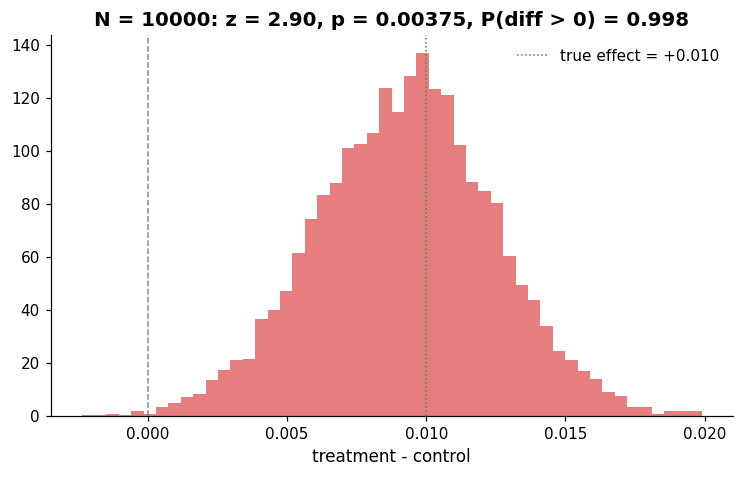

In [3]:
show_two_arm(10000)

## Loop C: continuous outcome (revenue per user)

Welch's t-test plus a bootstrap CI on the mean difference.

Welch t = 3.561,  p = 0.0003732
Bootstrap 95% CI on mean difference = [0.205, 0.698]


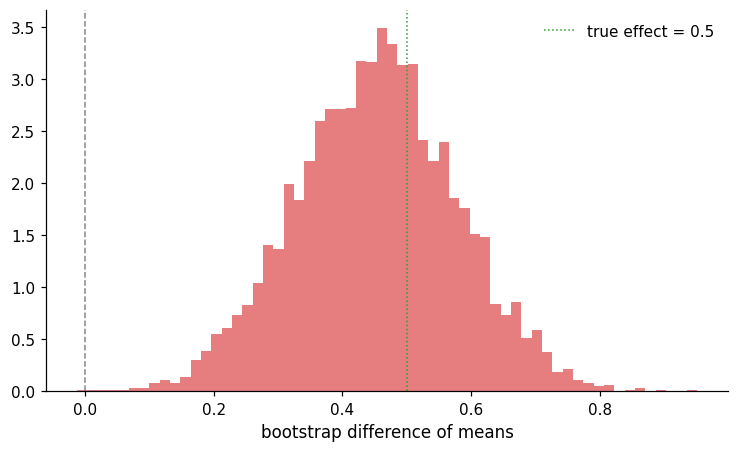

In [4]:
exp = two_arm_continuous(2000, mu_control=10.0, mu_treatment=10.5, sigma=4.0, seed=82)
t = two_sample_t(exp.treatment, exp.control, equal_var=False)
lo, hi, draws = bootstrap_diff_ci(exp.treatment, exp.control, n_boot=4000, seed=0)
print(f'Welch t = {t.statistic:.3f},  p = {t.p_value:.4g}')
print(f'Bootstrap 95% CI on mean difference = [{lo:.3f}, {hi:.3f}]')
fig, ax = plt.subplots()
ax.hist(draws, bins=60, density=True, color=PALETTE['bayesian'], alpha=0.6)
ax.axvline(0, color=PALETTE['muted'], linestyle='--', linewidth=1)
ax.axvline(0.5, color=PALETTE['highlight'], linestyle=':', linewidth=1, label='true effect = 0.5')
ax.set_xlabel('bootstrap difference of means'); ax.legend(); plt.show()

## Loop D: stratification

200 power-users (30% baseline) + 1800 casuals (5% baseline). Treatment lifts each by 2pp. The pooled view is dominated by the casuals.

In [5]:
strata = stratified_binary({'power-users': 200, 'casual': 1800}, {'power-users': (0.30, 0.32), 'casual': (0.05, 0.07)}, seed=83)
for name, s in strata.items():
    n = len(s.control)
    z = two_proportion_z(int(s.treatment.sum()), n, int(s.control.sum()), n)
    print(f'{name:<14} n_per_arm={n:>4}  diff = {s.treatment.mean()-s.control.mean():+.3f}  p = {z.p_value:.4g}')
c = np.concatenate([s.control for s in strata.values()])
t = np.concatenate([s.treatment for s in strata.values()])
z = two_proportion_z(int(t.sum()), len(t), int(c.sum()), len(c))
print(f'pooled         n_per_arm={len(t):>4}  diff = {t.mean()-c.mean():+.3f}  p = {z.p_value:.4g}')

power-users    n_per_arm= 200  diff = +0.055  p = 0.2448
casual         n_per_arm=1800  diff = +0.024  p = 0.0018
pooled         n_per_arm=2000  diff = +0.027  p = 0.002084


## Loop E: decision rule comparison

Frequentist: ship if (p < 0.05) AND (point estimate > 0). Bayesian: ship if P(diff > MMU) > 0.95. Vary the truth, see how often each lens ships.

In [6]:
def ship_rates(true_diff, n=2000, n_runs=200, mmu=0.005, seed=0):
    rng = np.random.default_rng(seed)
    f_ships = b_ships = 0
    for _ in range(n_runs):
        exp = two_arm_binary(n, 0.10, max(0.001, min(0.999, 0.10 + true_diff)), seed=int(rng.integers(0, 2**30)))
        z = two_proportion_z(int(exp.treatment.sum()), n, int(exp.control.sum()), n)
        if z.p_value < 0.05 and z.point_estimate > 0:
            f_ships += 1
        a_c, b_c = 1 + int(exp.control.sum()), 1 + (n - int(exp.control.sum()))
        a_t, b_t = 1 + int(exp.treatment.sum()), 1 + (n - int(exp.treatment.sum()))
        local = np.random.default_rng(0)
        diffs = local.beta(a_t, b_t, 2000) - local.beta(a_c, b_c, 2000)
        if (diffs > mmu).mean() > 0.95:
            b_ships += 1
    return f_ships / n_runs, b_ships / n_runs
for d in [-0.01, 0.0, 0.005, 0.01, 0.02]:
    f, b = ship_rates(d)
    print(f'true diff = {d:+.3f}:  F ship = {f:.2f}   B ship = {b:.2f}')

true diff = -0.010:  F ship = 0.00   B ship = 0.00


true diff = +0.000:  F ship = 0.01   B ship = 0.01
true diff = +0.005:  F ship = 0.07   B ship = 0.02


true diff = +0.010:  F ship = 0.15   B ship = 0.12


true diff = +0.020:  F ship = 0.48   B ship = 0.41
